In [1]:
pip install pandas numpy matplotlib seaborn

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 2.1/2.5 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.1 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.w

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


           SALES SUMMARY KPIs          
Total Revenue:      $1,184,928.45
Total Orders:       1,000
Total Units Sold:   4,893
Avg Order Value:    $1,184.93

Sales Performance by Category:
      Category     Revenue  Units_Sold  Avg_Price
      Clothing 323456.0430        1301 274.755922
   Electronics 307954.9135        1251 268.793164
         Books 294856.3085        1230 265.808095
Home & Kitchen 258661.1835        1111 260.437131




C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\1174683972.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\1174683972.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\1174683972.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


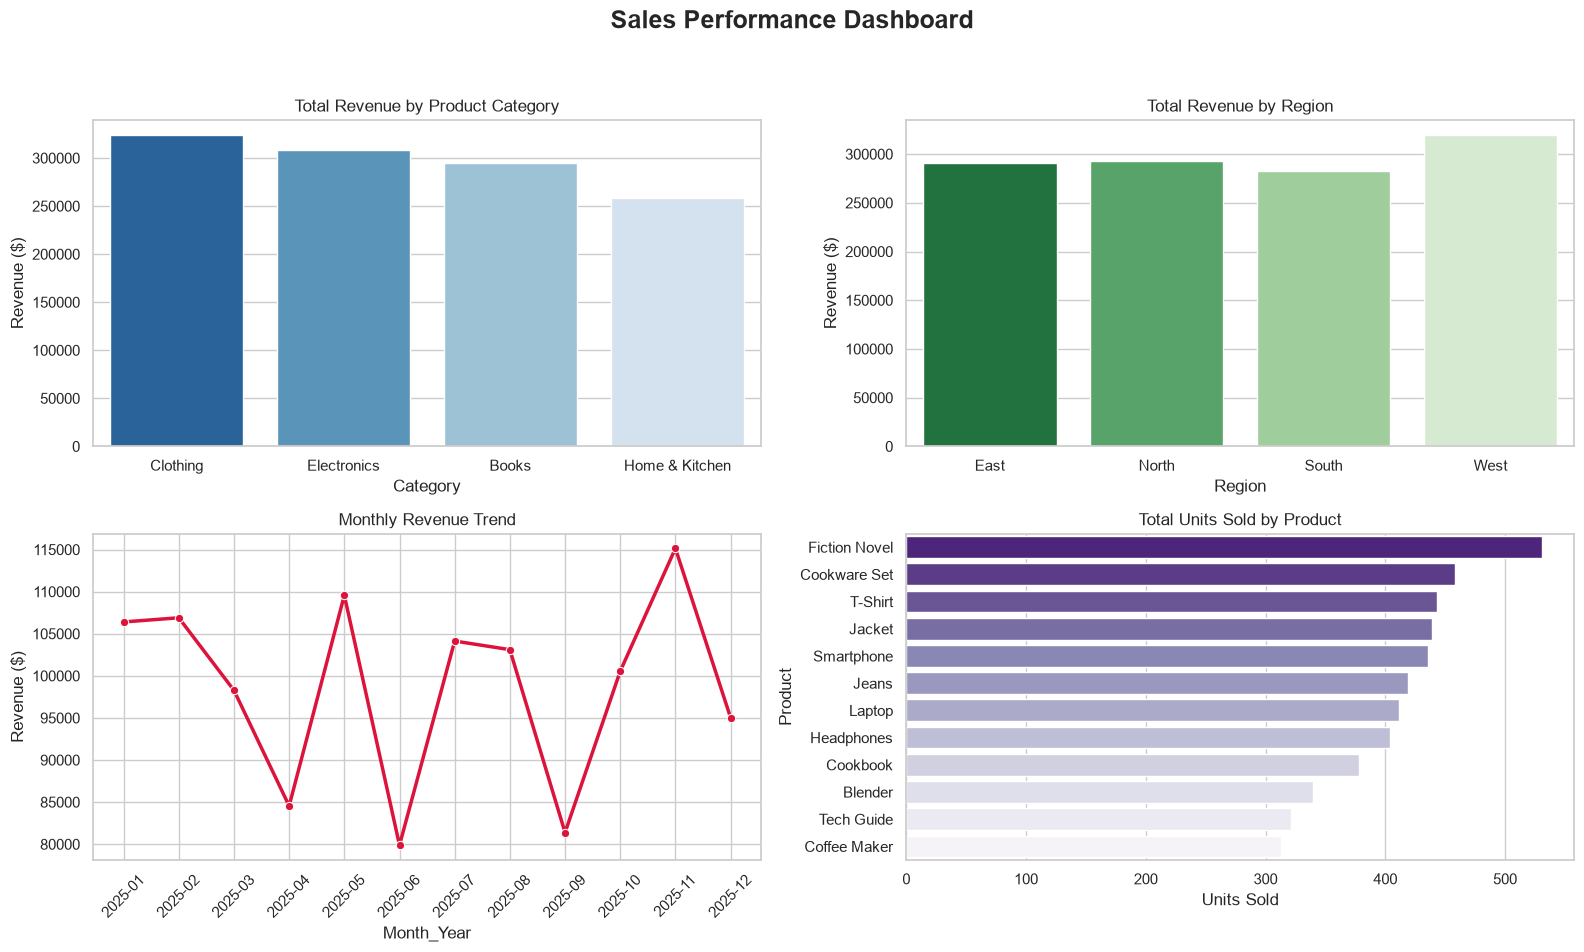

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================
# STEP 1: Generate Synthetic Sales Dataset
# ==========================================
np.random.seed(42)
num_records = 1000

dates = pd.date_range(start="2025-01-01", end="2025-12-31", periods=num_records)
categories = ["Electronics", "Clothing", "Home & Kitchen", "Books"]
products = {
    "Electronics": ["Laptop", "Smartphone", "Headphones"],
    "Clothing": ["T-Shirt", "Jeans", "Jacket"],
    "Home & Kitchen": ["Blender", "Coffee Maker", "Cookware Set"],
    "Books": ["Fiction Novel", "Tech Guide", "Cookbook"]
}
regions = ["North", "South", "East", "West"]

data = []
for i in range(num_records):
    category = np.random.choice(categories)
    product = np.random.choice(products[category])
    region = np.random.choice(regions)
    unit_price = np.random.uniform(10, 500)
    quantity = np.random.randint(1, 10)
    discount = np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20])
    
    data.append({
        "Order_ID": 1000 + i,
        "Order_Date": np.random.choice(dates),
        "Category": category,
        "Product": product,
        "Region": region,
        "Unit_Price": round(unit_price, 2),
        "Quantity": quantity,
        "Discount": discount
    })

df = pd.DataFrame(data)

# ==========================================
# STEP 2: Data Cleaning & Feature Engineering
# ==========================================
# Calculate Total Sales revenue and Net Profit (assuming 30% base cost)
df["Gross_Sales"] = df["Unit_Price"] * df["Quantity"]
df["Net_Sales"] = df["Gross_Sales"] * (1 - df["Discount"])
df["Month_Year"] = df["Order_Date"].dt.to_period("M")
df["Month"] = df["Order_Date"].dt.strftime("%B")

# ==========================================
# STEP 3: Key Business Metrics (KPIs)
# ==========================================
total_revenue = df["Net_Sales"].sum()
total_orders = df["Order_ID"].nunique()
avg_order_value = df["Net_Sales"].mean()
total_units_sold = df["Quantity"].sum()

print("="*40)
print("           SALES SUMMARY KPIs          ")
print("="*40)
print(f"Total Revenue:      ${total_revenue:,.2f}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Units Sold:   {total_units_sold:,}")
print(f"Avg Order Value:    ${avg_order_value:,.2f}")
print("="*40 + "\n")

# ==========================================
# STEP 4: Aggregations & Analysis
# ==========================================
# 1. Performance by Category
category_summary = df.groupby("Category").agg(
    Revenue=("Net_Sales", "sum"),
    Units_Sold=("Quantity", "sum"),
    Avg_Price=("Unit_Price", "mean")
).reset_index().sort_values(by="Revenue", ascending=False)

# 2. Performance by Region
region_summary = df.groupby("Region")["Net_Sales"].sum().reset_index()

# 3. Monthly Sales Trend
monthly_trend = df.groupby("Month_Year")["Net_Sales"].sum().reset_index()
monthly_trend["Month_Year"] = monthly_trend["Month_Year"].astype(str)

print("Sales Performance by Category:")
print(category_summary.to_string(index=False))
print("\n" + "="*40 + "\n")

# ==========================================
# STEP 5: Data Visualization
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sales Performance Dashboard", fontsize=18, fontweight="bold")

# Chart 1: Revenue by Category
sns.barplot(
    data=category_summary, 
    x="Category", 
    y="Revenue", 
    ax=axes[0, 0], 
    palette="Blues_r"
)
axes[0, 0].set_title("Total Revenue by Product Category")
axes[0, 0].set_ylabel("Revenue ($)")

# Chart 2: Revenue by Region
sns.barplot(
    data=region_summary, 
    x="Region", 
    y="Net_Sales", 
    ax=axes[0, 1], 
    palette="Greens_r"
)
axes[0, 1].set_title("Total Revenue by Region")
axes[0, 1].set_ylabel("Revenue ($)")

# Chart 3: Monthly Sales Trend
sns.lineplot(
    data=monthly_trend, 
    x="Month_Year", 
    y="Net_Sales", 
    marker="o", 
    ax=axes[1, 0], 
    color="crimson", 
    linewidth=2.5
)
axes[1, 0].set_title("Monthly Revenue Trend")
axes[1, 0].set_ylabel("Revenue ($)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Chart 4: Quantity Sold by Product
top_products = df.groupby("Product")["Quantity"].sum().reset_index().sort_values(by="Quantity", ascending=False)
sns.barplot(
    data=top_products, 
    x="Quantity", 
    y="Product", 
    ax=axes[1, 1], 
    palette="Purples_r"
)
axes[1, 1].set_title("Total Units Sold by Product")
axes[1, 1].set_xlabel("Units Sold")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
pip install pandas numpy matplotlib seaborn fpdf2


   ---------------------------------------- 0/2 [defusedxml]
   -------------------- ------------------- 1/2 [fpdf2]
   -------------------- ------------------- 1/2 [fpdf2]
   -------------------- ------------------- 1/2 [fpdf2]
   -------------------- ------------------- 1/2 [fpdf2]
   -------------------- ------------------- 1/2 [fpdf2]
   -------------------- ------------------- 1/2 [fpdf2]
   ---------------------------------------- 2/2 [fpdf2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF

# Set style for plots
sns.set_theme(style="whitegrid")

# ==========================================
# STEP 1: Generate Synthetic Sales Dataset
# ==========================================
np.random.seed(42)
num_records = 1000

dates = pd.date_range(start="2025-01-01", end="2025-12-31", periods=num_records)
categories = ["Electronics", "Clothing", "Home & Kitchen", "Books"]
products = {
    "Electronics": ["Laptop", "Smartphone", "Headphones"],
    "Clothing": ["T-Shirt", "Jeans", "Jacket"],
    "Home & Kitchen": ["Blender", "Coffee Maker", "Cookware Set"],
    "Books": ["Fiction Novel", "Tech Guide", "Cookbook"]
}
regions = ["North", "South", "East", "West"]

data = []
for i in range(num_records):
    category = np.random.choice(categories)
    product = np.random.choice(products[category])
    region = np.random.choice(regions)
    unit_price = np.random.uniform(10, 500)
    quantity = np.random.randint(1, 10)
    discount = np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20])
    
    data.append({
        "Order_ID": 1000 + i,
        "Order_Date": np.random.choice(dates),
        "Category": category,
        "Product": product,
        "Region": region,
        "Unit_Price": round(unit_price, 2),
        "Quantity": quantity,
        "Discount": discount
    })

df = pd.DataFrame(data)

# ==========================================
# STEP 2: Data Processing & Metrics
# ==========================================
df["Gross_Sales"] = df["Unit_Price"] * df["Quantity"]
df["Net_Sales"] = df["Gross_Sales"] * (1 - df["Discount"])
df["Month_Year"] = df["Order_Date"].dt.to_period("M")

# Metrics
total_revenue = df["Net_Sales"].sum()
total_orders = df["Order_ID"].nunique()
avg_order_value = df["Net_Sales"].mean()
total_units_sold = df["Quantity"].sum()

category_summary = df.groupby("Category").agg(
    Revenue=("Net_Sales", "sum"),
    Units_Sold=("Quantity", "sum"),
    Avg_Price=("Unit_Price", "mean")
).reset_index().sort_values(by="Revenue", ascending=False)

region_summary = df.groupby("Region")["Net_Sales"].sum().reset_index()
monthly_trend = df.groupby("Month_Year")["Net_Sales"].sum().reset_index()
monthly_trend["Month_Year"] = monthly_trend["Month_Year"].astype(str)

# ==========================================
# STEP 3: Generate & Save Dashboard Image
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Sales Performance Dashboard", fontsize=16, fontweight="bold")

sns.barplot(data=category_summary, x="Category", y="Revenue", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Revenue by Category")
axes[0, 0].set_ylabel("Revenue ($)")

sns.barplot(data=region_summary, x="Region", y="Net_Sales", ax=axes[0, 1], palette="Greens_r")
axes[0, 1].set_title("Revenue by Region")
axes[0, 1].set_ylabel("Revenue ($)")

sns.lineplot(data=monthly_trend, x="Month_Year", y="Net_Sales", marker="o", ax=axes[1, 0], color="crimson")
axes[1, 0].set_title("Monthly Revenue Trend")
axes[1, 0].set_ylabel("Revenue ($)")
axes[1, 0].tick_params(axis="x", rotation=45)

top_products = df.groupby("Product")["Quantity"].sum().reset_index().sort_values(by="Quantity", ascending=False)
sns.barplot(data=top_products, x="Quantity", y="Product", ax=axes[1, 1], palette="Purples_r")
axes[1, 1].set_title("Units Sold by Product")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
chart_filename = "sales_dashboard.png"
plt.savefig(chart_filename, dpi=300)
plt.close()

# ==========================================
# STEP 4: Build PDF Report with FPDF
# ==========================================
class PDFReport(FPDF):
    def header(self):
        self.set_font("Helvetica", "B", 16)
        self.cell(0, 10, "Executive Sales Analysis Report", border=False, new_x="LMARGIN", new_y="NEXT", align="C")
        self.set_font("Helvetica", "I", 10)
        self.cell(0, 5, "Automated Business Performance Overview", border=False, new_x="LMARGIN", new_y="NEXT", align="C")
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font("Helvetica", "I", 8)
        self.cell(0, 10, f"Page {self.page_no()}", align="C")

pdf = PDFReport()
pdf.add_page()

# --- KPI Section ---
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 8, "Key Performance Indicators", new_x="LMARGIN", new_y="NEXT")

pdf.set_font("Helvetica", "", 10)
kpi_text = (
    f"Total Revenue: ${total_revenue:,.2f}  |  "
    f"Total Orders: {total_orders:,}  |  "
    f"Units Sold: {total_units_sold:,}  |  "
    f"Avg Order Value: ${avg_order_value:,.2f}"
)
pdf.cell(0, 8, kpi_text, border=True, new_x="LMARGIN", new_y="NEXT", align="C")
pdf.ln(5)

# --- Category Breakdown Table ---
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 8, "Category Performance Breakdown", new_x="LMARGIN", new_y="NEXT")

# Table Headers
pdf.set_font("Helvetica", "B", 9)
col_widths = [50, 45, 45, 45]
headers = ["Category", "Revenue ($)", "Units Sold", "Avg Unit Price ($)"]

for width, header in zip(col_widths, headers):
    pdf.cell(width, 7, header, border=1, align="C")
pdf.ln()

# Table Rows
pdf.set_font("Helvetica", "", 9)
for _, row in category_summary.iterrows():
    pdf.cell(col_widths[0], 6, str(row["Category"]), border=1)
    pdf.cell(col_widths[1], 6, f"${row['Revenue']:,.2f}", border=1, align="R")
    pdf.cell(col_widths[2], 6, f"{row['Units_Sold']:,}", border=1, align="R")
    pdf.cell(col_widths[3], 6, f"${row['Avg_Price']:,.2f}", border=1, align="R")
    pdf.ln()

pdf.ln(6)

# --- Charts Dashboard Section ---
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 8, "Visual Performance Analytics", new_x="LMARGIN", new_y="NEXT")
pdf.image(chart_filename, x=10, y=pdf.get_y(), w=190)

# Save Document
pdf_filename = "Sales_Analysis_Report.pdf"
pdf.output(pdf_filename)

# Cleanup temp image file
if os.path.exists(chart_filename):
    os.remove(chart_filename)

print(f"Report successfully generated and saved as '{pdf_filename}'.")

C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\705612108.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary, x="Category", y="Revenue", ax=axes[0, 0], palette="Blues_r")
C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\705612108.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary, x="Region", y="Net_Sales", ax=axes[0, 1], palette="Greens_r")
C:\Users\nazmu\AppData\Local\Temp\ipykernel_8088\705612108.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x="Quantity", y="Product"

Report successfully generated and saved as 'Sales_Analysis_Report.pdf'.


In [6]:
pip install streamlit pandas numpy plotly

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/10.5 MB 8.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/10.5 MB 5.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/10.5 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/10.5 MB 4.6 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/10.5 MB 4.4 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.5 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 6.0/10.5 MB 4.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.8/10.5 MB 4.1 MB/s eta 0:00:01
   ---------------------------- ----------- 7.6/10.5 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.5 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.9/10.5 MB 4.0 MB/s eta 0:00:01
   ------------------------------------ --- 9.7/10.5 MB 3.9 MB/s eta 0:00:01
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ==========================================
# PAGE CONFIGURATION
# ==========================================
st.set_page_config(
    page_title="Executive Business Dashboard",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for styling cards and layout
st.markdown("""
<style>
    .metric-card {
        background-color: #f8f9fa;
        border-radius: 10px;
        padding: 15px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        text-align: center;
    }
    .metric-value {
        font-size: 24px;
        font-weight: bold;
        color: #1f77b4;
    }
    .metric-label {
        font-size: 14px;
        color: #6c757d;
    }
</style>
""", unsafe_allow_html=True)

# ==========================================
# STEP 1: Generate Synthetic Business Data
# ==========================================
@st.cache_data
def load_data():
    np.random.seed(42)
    num_records = 1500

    dates = pd.date_range(start="2025-01-01", end="2025-12-31", periods=num_records)
    categories = ["Electronics", "Clothing", "Home & Kitchen", "Books"]
    products = {
        "Electronics": ["Laptop", "Smartphone", "Headphones"],
        "Clothing": ["T-Shirt", "Jeans", "Jacket"],
        "Home & Kitchen": ["Blender", "Coffee Maker", "Cookware"],
        "Books": ["Fiction", "Tech Guide", "Cookbook"]
    }
    regions = ["North", "South", "East", "West"]

    records = []
    for i in range(num_records):
        cat = np.random.choice(categories)
        prod = np.random.choice(products[cat])
        reg = np.random.choice(regions)
        price = round(np.random.uniform(15, 600), 2)
        qty = np.random.randint(1, 8)
        discount = np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20])
        
        records.append({
            "Order_ID": 1000 + i,
            "Date": np.random.choice(dates),
            "Category": cat,
            "Product": prod,
            "Region": reg,
            "Unit_Price": price,
            "Quantity": qty,
            "Discount": discount
        })

    df = pd.DataFrame(records)
    df["Gross_Sales"] = df["Unit_Price"] * df["Quantity"]
    df["Net_Sales"] = df["Gross_Sales"] * (1 - df["Discount"])
    df["Month_Year"] = df["Date"].dt.to_period("M").astype(str)
    return df

df = load_data()

# ==========================================
# STEP 2: Sidebar Dynamic Filters
# ==========================================
st.sidebar.header("🔍 Filter Dashboard")

# Region Filter
selected_region = st.sidebar.multiselect(
    "Select Region(s):",
    options=df["Region"].unique(),
    default=df["Region"].unique()
)

# Category Filter
selected_category = st.sidebar.multiselect(
    "Select Category:",
    options=df["Category"].unique(),
    default=df["Category"].unique()
)

# Date Range Filter
min_date = df["Date"].min().date()
max_date = df["Date"].max().date()

start_date, end_date = st.sidebar.date_input(
    "Select Date Range:",
    value=[min_date, max_date],
    min_value=min_date,
    max_value=max_date
)

# Apply Filters
filtered_df = df[
    (df["Region"].isin(selected_region)) &
    (df["Category"].isin(selected_category)) &
    (df["Date"].dt.date >= start_date) &
    (df["Date"].dt.date <= end_date)
]

# ==========================================
# STEP 3: Dashboard Header & KPI Metrics
# ==========================================
st.title("📊 Executive Sales & Operations Dashboard")
st.markdown("Real-time dynamic overview of operational sales metrics.")

# Calculate Key Business KPIs
total_revenue = filtered_df["Net_Sales"].sum()
total_orders = filtered_df["Order_ID"].nunique()
avg_order_value = filtered_df["Net_Sales"].mean() if not filtered_df.empty else 0
total_units = filtered_df["Quantity"].sum()

# Display KPIs in 4 Columns
kpi1, kpi2, kpi3, kpi4 = st.columns(4)

with kpi1:
    st.metric("Total Revenue", f"${total_revenue:,.2f}")

with kpi2:
    st.metric("Total Orders", f"{total_orders:,}")

with kpi3:
    st.metric("Avg Order Value", f"${avg_order_value:,.2f}")

with kpi4:
    st.metric("Units Sold", f"{total_units:,}")

st.markdown("---")

# ==========================================
# STEP 4: Visualizations Grid
# ==========================================
if filtered_df.empty:
    st.warning("No data available for the selected filters.")
else:
    col1, col2 = st.columns(2)

    with col1:
        # Monthly Revenue Line Chart
        monthly_sales = filtered_df.groupby("Month_Year")["Net_Sales"].sum().reset_index()
        fig_line = px.line(
            monthly_sales, 
            x="Month_Year", 
            y="Net_Sales", 
            title="📈 Monthly Revenue Performance",
            markers=True,
            line_shape="spline"
        )
        fig_line.update_layout(xaxis_title="Month", yaxis_title="Net Sales ($)")
        st.plotly_chart(fig_line, use_container_width=True)

    with col2:
        # Revenue by Category Bar Chart
        cat_sales = filtered_df.groupby("Category")["Net_Sales"].sum().reset_index().sort_values(by="Net_Sales", ascending=False)
        fig_bar = px.bar(
            cat_sales, 
            x="Category", 
            y="Net_Sales", 
            color="Category",
            title="🏷️ Revenue Share by Category",
            text_auto=".2s"
        )
        fig_bar.update_layout(yaxis_title="Net Sales ($)")
        st.plotly_chart(fig_bar, use_container_width=True)

    col3, col4 = st.columns(2)

    with col3:
        # Regional Distribution Donut Chart
        reg_sales = filtered_df.groupby("Region")["Net_Sales"].sum().reset_index()
        fig_donut = px.pie(
            reg_sales, 
            values="Net_Sales", 
            names="Region", 
            title="🌍 Regional Revenue Breakdown",
            hole=0.4
        )
        st.plotly_chart(fig_donut, use_container_width=True)

    with col4:
        # Top 5 Best-Selling Products Horizontal Bar Chart
        top_prods = filtered_df.groupby("Product")["Quantity"].sum().reset_index().sort_values(by="Quantity", ascending=True).tail(5)
        fig_top = px.bar(
            top_prods, 
            x="Quantity", 
            y="Product", 
            orientation="h",
            title="⭐ Top 5 Best-Selling Products (Volume)",
            color="Quantity",
            color_continuous_scale="Purples"
        )
        st.plotly_chart(fig_top, use_container_width=True)

# ==========================================
# STEP 5: Detailed Data Table & Export
# ==========================================
st.markdown("---")
st.subheader("📋 Raw Order Data")

with st.expander("Expand to view detailed order table"):
    st.dataframe(filtered_df, use_container_width=True)
    
    # Download CSV Button
    csv_data = filtered_df.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="📥 Download Filtered Data as CSV",
        data=csv_data,
        file_name="filtered_sales_data.csv",
        mime="text/csv"
    )

2026-09-11 01:00:05.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.792 No runtime found, using MemoryCacheStorageManager
2026-09-11 01:00:05.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.797 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 01:00:05.800 Thread 'MainThread':